<a href="https://colab.research.google.com/github/keyonai/OCR-practice/blob/main/Keyonaiwilliams_Analyze_a_Scanned_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
original image:


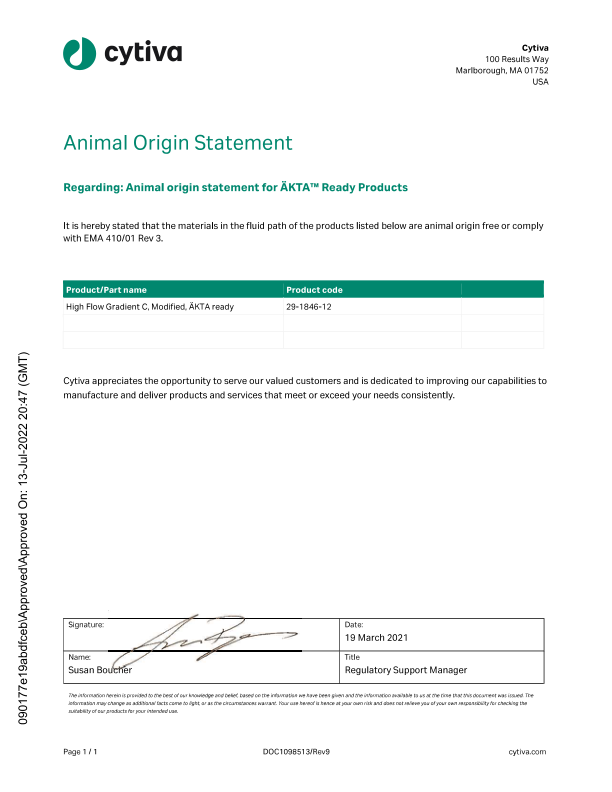

preprocessed image:


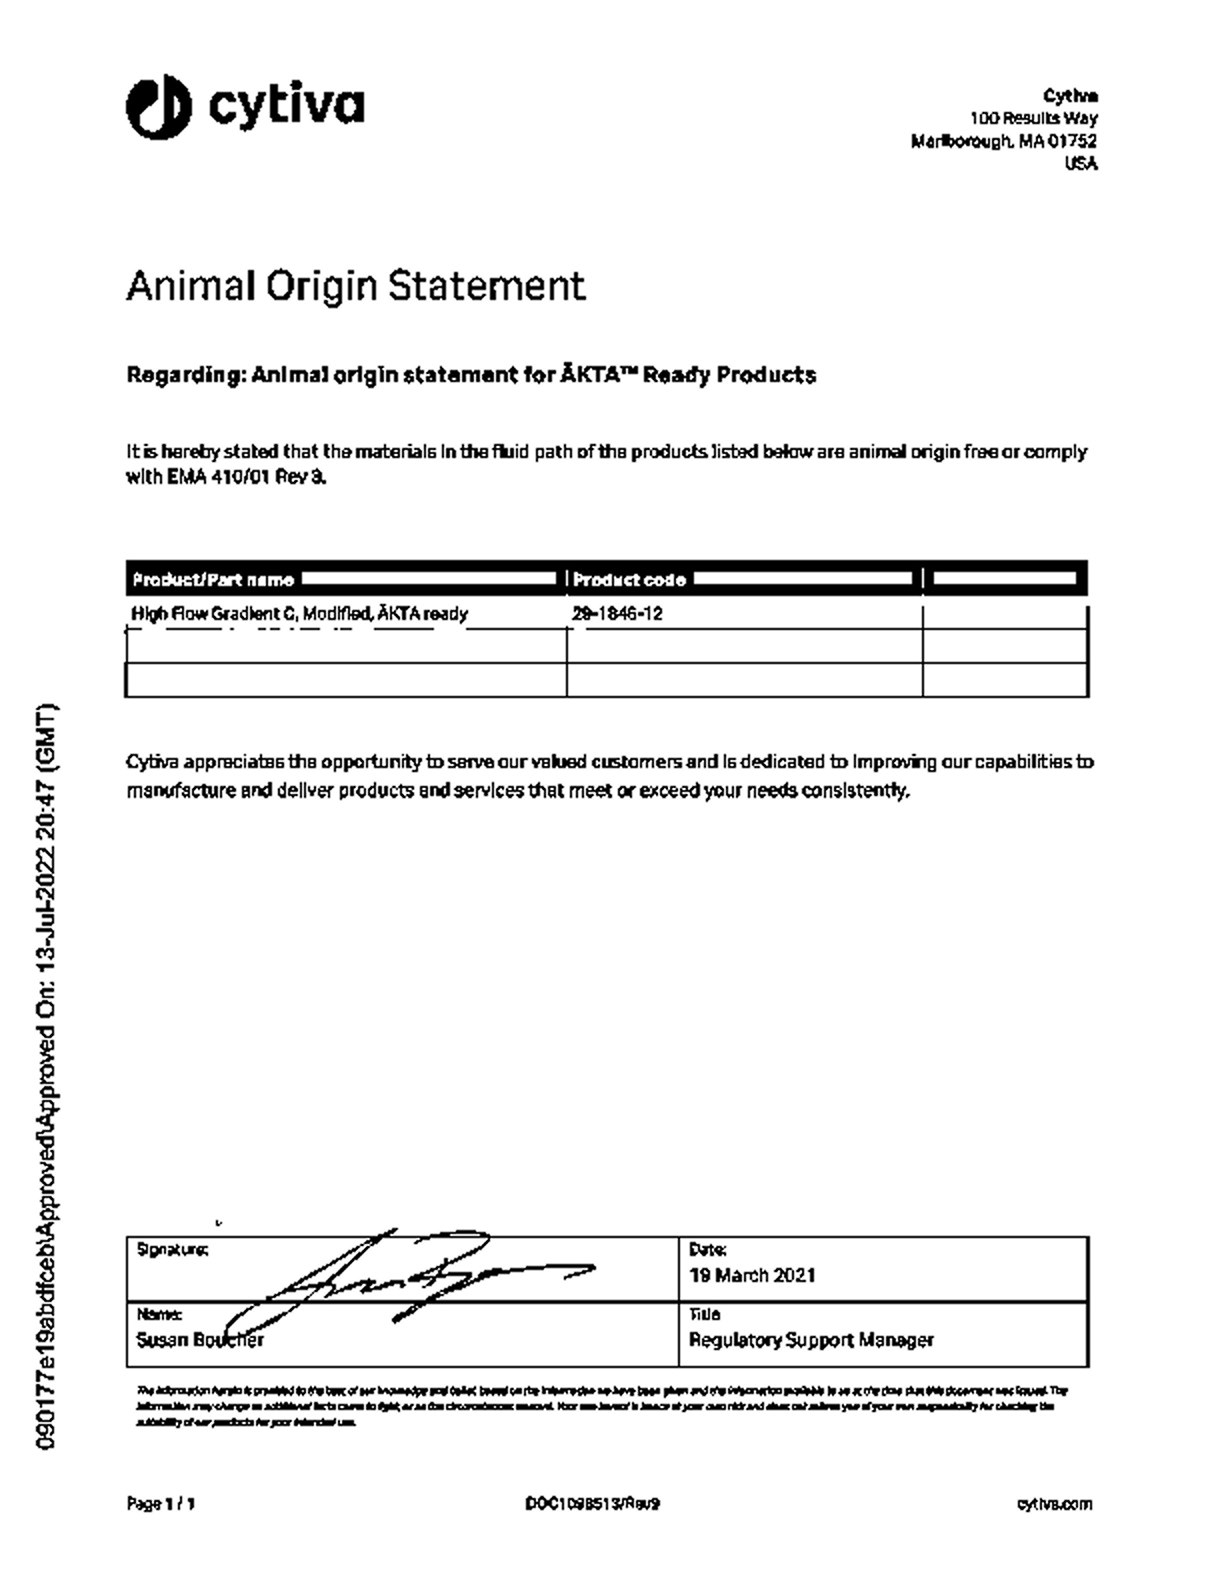

OCR Extracted Text:

090177e19abdfceb\Approved\Approved On: 13-Juk-2022 20:47 (GMT)

2
¢) cytiva —_
Marlborough. MA 01752
USA

Animal Origin Statement

Regarding: Anima origin statamant for AKTA™ Ready Products

Itis hareby stated that the materials In the fluid path of the products listed below ara animal origin free ar comply
with EMA 410/01 Rev 2,

De I I
High Flow Gradent ©, Modified, AKTA ready 21846-12 |

 

Cytiva appreciates the opportunity to serve aur valued custamers and Is dedicated to Improving our capabilitias to
manufacture and deliver products and services that meet or exceed your needs cansistently,

 

 

Sipnkure, Date:
19 March 2021
Nese Tue
Susan B r Regulatory Support Manager

 

ss Leasheanallachambadalemasdabideskaherbes reasted aad enahiaaubalidiarthdambennded amLastlsh kbdesenpneunaen ubsdahdomdaabtabocethratpabicotied
Anbrrmun my charge mm action brts Care to fight ar a Com Cretan CAL Her mY RAC a yom cr AS ae cn? ren ye wr ran smepmaatcy Par cag
mitablity cf

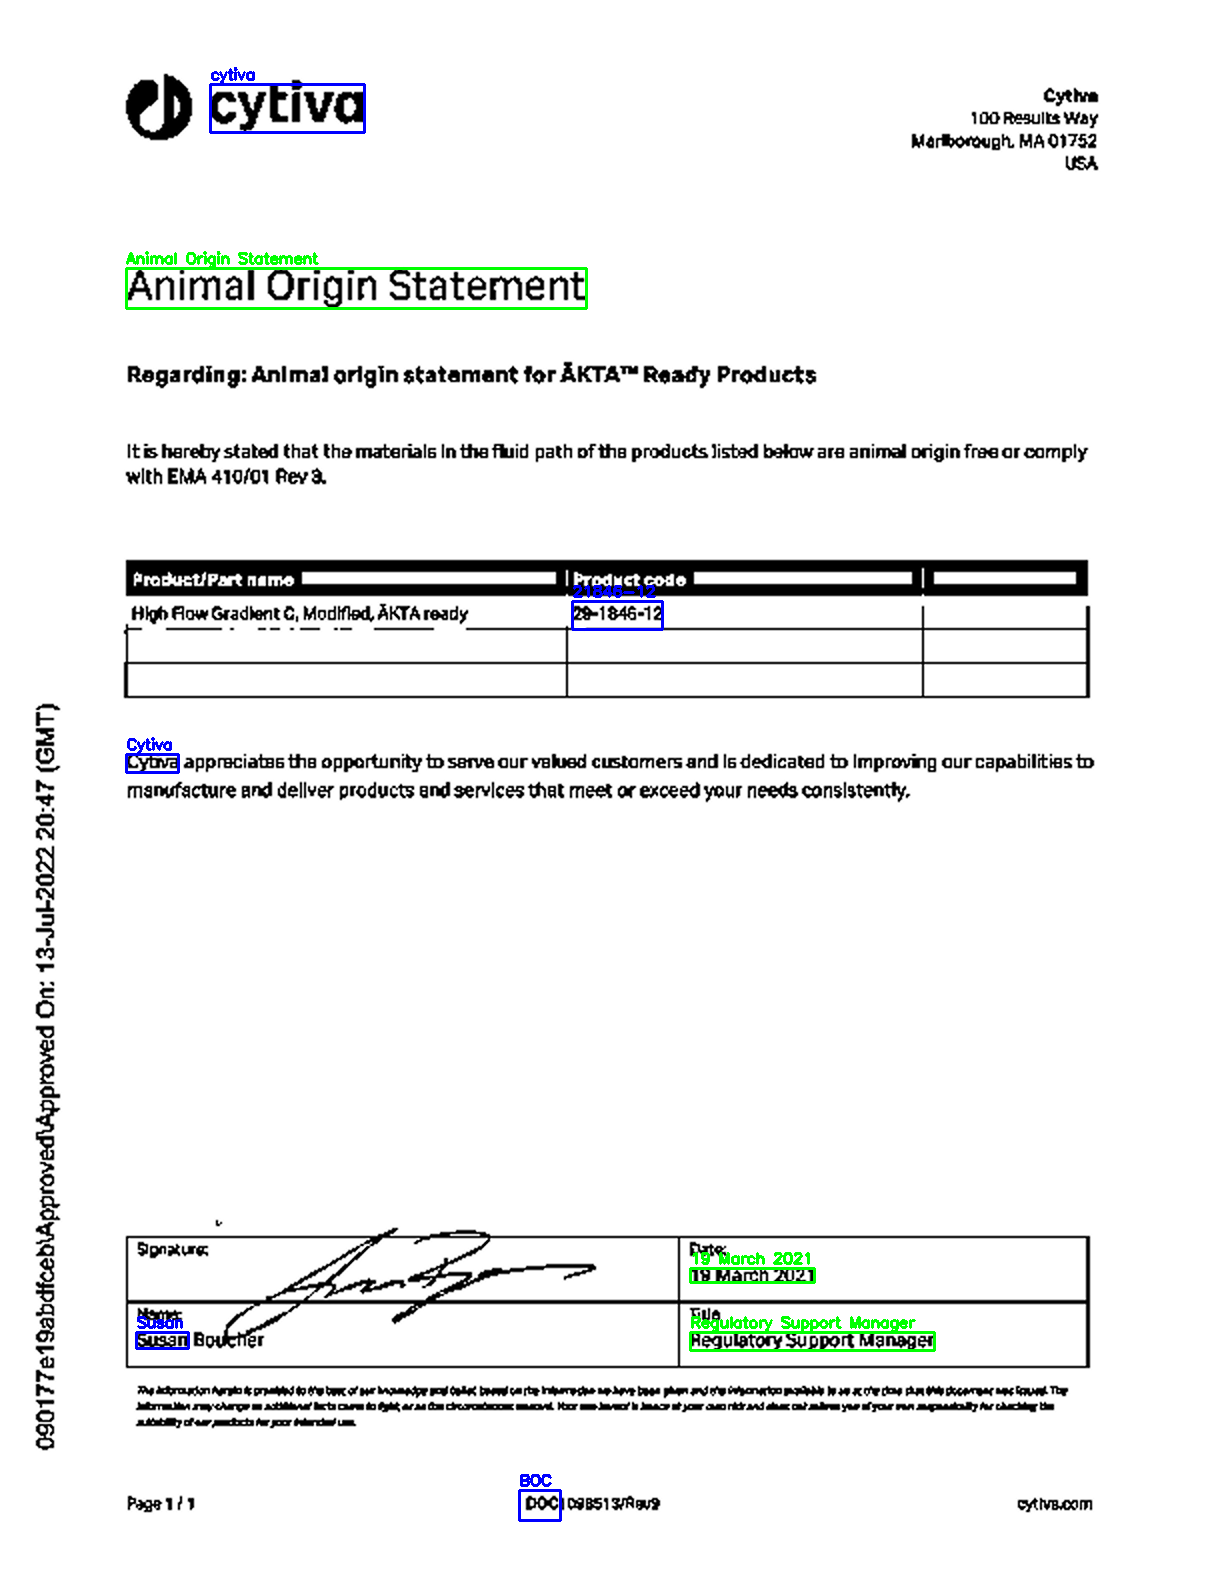

In [ ]:
#have to install tesseract
!apt install -y tesseract-ocr
!pip install pymupdf pytesseract opencv-python pillow numpy

import  cv2
import fitz
import numpy as np
import pytesseract
from PIL import Image

# Load the scanned PDF
pdf_path = "pharmaceutical-sdf-page2-animal-origin.pdf"  # Update this path if needed
doc = fitz.open(pdf_path)

page = doc[0]

 # Convert the first page to an image
pix = page.get_pixmap()
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

# Display the image
print('original image:')
display(img)



# Convert the image to grayscale
img = np.array(img)  # Convert PIL image to NumPy array
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


# Apply adaptive thresholding to enhance contrast
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)


# Apply Bilateral Filtering for noise reduction
gray = cv2.bilateralFilter(gray, 9, 75, 75)


# Resize image for better OCR accuracy
scale_percent = 200  # Increase image size by 200%
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

# Display the resized image
print('preprocessed image:')
display(Image.fromarray(gray))

# Run OCR on the preprocessed image
custom_config = r'--oem 3 -l eng'
ocr_text = pytesseract.image_to_string(gray, config=custom_config)

# Print extracted text
print("OCR Extracted Text:\n")
print(ocr_text)


import re

# Fix common OCR errors in pharmaceutical documents
ocr_text = re.sub(r'\bAnima\b', 'Animal', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bhareby\b', 'hereby', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bSipnkure\b', 'Signature', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bar\b', 'or', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bcansistently\b', 'consistently', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\baur\b', 'our', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bcustamers\b', 'customers', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bGradent\b', 'Gradient C', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\b21846-12\b', '28-1846-12', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bSusan B r\b', 'Susan Boucher', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'\bBOC\b', 'DOC', ocr_text, flags=re.IGNORECASE)
ocr_text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', ocr_text) # Remove unwanted symbols

print("Corrected OCR Text:\n", ocr_text)


# Define the key fields we care about in pharmaceutical documents
key_fields = [
    "Cytiva",
    "High Flow Gradient C , Modified, AKTA ready",
    "28-1846-12",
    "Animal Origin Statement",
    "Signature",
    "19 March 2021",
    "Susan",
    "Regulatory Support Manager",
    "DOC"
]
ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)
# Create a fresh copy of the original image
img_key_fields = cv2.cvtColor(gray.copy(), cv2.COLOR_BGR2RGB) # Changed to RGB here to match display

highlighted_count = 0
# Create a set of lowercase, stripped key fields for efficient and case-insensitive lookup
processed_key_fields_lower = {field.strip().lower() for field in key_fields}

# Separate single-word and multi-word key fields
single_word_key_fields = {field for field in processed_key_fields_lower if len(field.split()) == 1}
multi_word_key_fields = [field for field in key_fields if len(field.split()) > 1]

# Function to apply the same OCR corrections to a given text
def apply_ocr_corrections(text):
    text = re.sub(r'\bAnima\b', 'Animal', text, flags=re.IGNORECASE)
    text = re.sub(r'\bhareby\b', 'hereby', text, flags=re.IGNORECASE)
    text = re.sub(r'\bSipnkure\b', 'Signature', text, flags=re.IGNORECASE)
    text = re.sub(r'\bar\b', 'or', text, flags=re.IGNORECASE)
    text = re.sub(r'\bcansistently\b', 'consistently', text, flags=re.IGNORECASE)
    text = re.sub(r'\baur\b', 'our', text, flags=re.IGNORECASE)
    text = re.sub(r'\bcustamers\b', 'customers', text, flags=re.IGNORECASE)
    text = re.sub(r'\bGradent\b', 'Gradient C', text, flags=re.IGNORECASE)
    text = re.sub(r'\b21846-12\b', '28-1846-12', text, flags=re.IGNORECASE)
    text = re.sub(r'\bSusan B r\b', 'Susan Boucher', text, flags=re.IGNORECASE)
    text = re.sub(r'\bBOC\b', 'DOC', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', text) # Remove unwanted symbols
    return text

# Highlight single words
for i in range(len(ocr_data["text"])):
    original_word_ocr = ocr_data["text"][i]
    if not original_word_ocr.strip(): # Skip empty strings or strings with only whitespace
        continue
    corrected_word = apply_ocr_corrections(original_word_ocr).strip().lower()

    # Check if the corrected word (lowercase) is present in our single-word key fields
    if corrected_word in single_word_key_fields:
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]

        # Draw a RED rectangle and label
        cv2.rectangle(img_key_fields, (x, y), (x + w, y + h), (0, 0, 255), 2)
        # Use the original word from ocr_data for labeling (or corrected_word if preferred)
        cv2.putText(img_key_fields, original_word_ocr, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        highlighted_count += 1

# Function to find and highlight multi-word phrases
def highlight_multi_word_phrase(image, ocr_data, phrase, color=(0, 255, 0), thickness=2):
    global highlighted_count
    # The target phrase from key_fields is already considered 'correct'
    phrase_words_target = phrase.lower().split()
    num_phrase_words = len(phrase_words_target)

    # Pre-correct all OCR words for comparison
    corrected_ocr_words = [apply_ocr_corrections(word).strip() for word in ocr_data["text"]]

    for i in range(len(corrected_ocr_words) - num_phrase_words + 1):
        current_sequence = [
            corrected_ocr_words[j].lower() for j in range(i, i + num_phrase_words)
        ]
        if "" in current_sequence: # Skip if any word in sequence is empty after correction
            continue

        if current_sequence == phrase_words_target:
            # Found a match, now get bounding box for the entire phrase using original ocr_data indices
            x_min = min(ocr_data["left"][j] for j in range(i, i + num_phrase_words))
            y_min = min(ocr_data["top"][j] for j in range(i, i + num_phrase_words))
            x_max = max(ocr_data["left"][j] + ocr_data["width"][j] for j in range(i, i + num_phrase_words))
            y_max = max(ocr_data["top"][j] + ocr_data["height"][j] for j in range(i, i + num_phrase_words))

            # Draw a GREEN rectangle for phrases
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, thickness)
            cv2.putText(image, phrase, (x_min, y_min - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, thickness)
            highlighted_count += 1

    return image

# Highlight multi-word phrases
for phrase in multi_word_key_fields:
    img_key_fields = highlight_multi_word_phrase(img_key_fields, ocr_data, phrase, color=(0, 255, 0)) # Green for phrases

print(f"Found {highlighted_count} key pharmaceutical terms (including multi-word phrases):")
display(Image.fromarray(img_key_fields)) # Display the image with highlighted terms

In [ ]:
import json
import re

# Re-define apply_ocr_corrections to ensure it's in the current scope
def apply_ocr_corrections(text):
    text = re.sub(r'\bAnima\b', 'Animal', text, flags=re.IGNORECASE)
    text = re.sub(r'\bhareby\b', 'hereby', text, flags=re.IGNORECASE)
    text = re.sub(r'\bSipnkure\b', 'Signature', text, flags=re.IGNORECASE)
    text = re.sub(r'\bar\b', 'or', text, flags=re.IGNORECASE)
    text = re.sub(r'\bcansistently\b', 'consistently', text, flags=re.IGNORECASE)
    text = re.sub(r'\baur\b', 'our', text, flags=re.IGNORECASE)
    text = re.sub(r'\bcustamers\b', 'customers', text, flags=re.IGNORECASE)
    text = re.sub(r'\bGradent\b', 'Gradient C', text, flags=re.IGNORECASE)
    text = re.sub(r'\b21846-12\b', '28-1846-12', text, flags=re.IGNORECASE)
    text = re.sub(r'\bSusan B r\b', 'Susan Boucher', text, flags=re.IGNORECASE)
    text = re.sub(r'\bBOC\b', 'DOC', text, flags=re.IGNORECASE)
    text = re.sub(r'[^a-zA-Z0-9\s,.%-]', '', text) # Remove unwanted symbols
    return text

# Use the latest key_fields from the notebook state
key_fields = [
    "Cytiva",
    "High Flow Gradient C , Modified, AKTA ready",
    "28-1846-12",
    "Animal Origin Statement",
    "Signature",
    "19 March 2021",
    "Susan",
    "Regulatory Support Manager",
    "DOC"
]

structured_output = {field: [] for field in key_fields}

# Separate single-word and multi-word key fields (original form)
single_word_key_fields_original = []
multi_word_key_fields_original = []
for field in key_fields:
    if len(field.split()) == 1:
        single_word_key_fields_original.append(field)
    else:
        multi_word_key_fields_original.append(field)

# Pre-correct and lowercase all OCR words for efficient comparison
corrected_ocr_words_lower = [apply_ocr_corrections(word).strip().lower() for word in ocr_data["text"]]

# Helper function to get bounding box for a single word at a given index
def get_bbox(index):
    return {
        "x": ocr_data["left"][index],
        "y": ocr_data["top"][index],
        "w": ocr_data["width"][index],
        "h": ocr_data["height"][index]
    }

# Process single-word key fields
for i in range(len(ocr_data["text"])):
    corrected_word_ocr = corrected_ocr_words_lower[i]
    if not corrected_word_ocr: # Skip empty strings
        continue

    for original_key_field in single_word_key_fields_original:
        if corrected_word_ocr == apply_ocr_corrections(original_key_field).strip().lower():
            structured_output[original_key_field].append(get_bbox(i))

# Process multi-word key fields
for original_phrase in multi_word_key_fields_original:
    # Prepare the target phrase by applying corrections and splitting
    target_phrase_words_lower = apply_ocr_corrections(original_phrase).strip().lower().split()
    num_target_phrase_words = len(target_phrase_words_lower)

    if num_target_phrase_words == 0: # Handle empty phrase after correction
        continue

    for i in range(len(corrected_ocr_words_lower) - num_target_phrase_words + 1):
        # Extract a sequence of corrected OCR words for comparison
        current_ocr_sequence = corrected_ocr_words_lower[i : i + num_target_phrase_words]

        # Check if the current OCR sequence matches the target phrase
        if current_ocr_sequence == target_phrase_words_lower:
            # Found a match, calculate the bounding box for the entire phrase
            x_min = min(ocr_data["left"][j] for j in range(i, i + num_target_phrase_words))
            y_min = min(ocr_data["top"][j] for j in range(i, i + num_target_phrase_words))
            x_max = max(ocr_data["left"][j] + ocr_data["width"][j] for j in range(i, i + num_target_phrase_words))
            y_max = max(ocr_data["top"][j] + ocr_data["height"][j] for j in range(i, i + num_target_phrase_words))

            structured_output[original_phrase].append({
                "x": x_min,
                "y": y_min,
                "w": x_max - x_min,
                "h": y_max - y_min
            })

# Reformat the structured_output to the desired format
reformatted_output = {}
for key_field, bbox_list in structured_output.items():
    bounding_boxes_flat = []
    for bbox in bbox_list:
        bounding_boxes_flat.append([bbox["x"], bbox["y"], bbox["w"], bbox["h"]])
    reformatted_output[key_field] = {
        "text": key_field,
        "bounding_box": bounding_boxes_flat
    }

# Output the structured data as JSON
print(json.dumps(reformatted_output, indent=4))


{
    "Cytiva": {
        "text": "Cytiva",
        "bounding_box": [
            [
                210,
                84,
                154,
                48
            ],
            [
                126,
                754,
                52,
                18
            ]
        ]
    },
    "High Flow Gradient C , Modified, AKTA ready": {
        "text": "High Flow Gradient C , Modified, AKTA ready",
        "bounding_box": []
    },
    "28-1846-12": {
        "text": "28-1846-12",
        "bounding_box": [
            [
                572,
                601,
                90,
                28
            ]
        ]
    },
    "Animal Origin Statement": {
        "text": "Animal Origin Statement",
        "bounding_box": [
            [
                126,
                268,
                460,
                40
            ]
        ]
    },
    "Signature": {
        "text": "Signature",
        "bounding_box": []
    },
    "19 March 2021": {
        